# Project 4b — Module 5: Statistical Inference
## Lesson 4: Sampling Distribution & Central Limit Theorem

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 4 — Modeling |
| **Module** | 5 — Statistical Inference (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook empirically verifies the Central Limit Theorem (CLT) on
> PequeShop's `avg_ticket` variable. By drawing repeated samples of increasing
> sizes (n=10, 30, 50, 100, 200), we demonstrate that the sampling distribution
> of the mean converges to Normal regardless of the population distribution.
> This validates the use of t-tests and z-tests in notebook 06 even if
> `avg_ticket` is not perfectly Normal in the population.


## Table of Contents

1. [CRISP-DM Phase 4 — Modeling](#1-crisp-dm-phase-4--modeling)
2. [Load Data](#2-load-data)
3. [Population Distribution — avg_ticket](#3-population-distribution--avg_ticket)
4. [Central Limit Theorem — Empirical Verification](#4-central-limit-theorem--empirical-verification)
5. [Standard Error — SE = sigma / sqrt(n)](#5-standard-error--se--sigma--sqrtn)
6. [CLT Summary — Test Validity Confirmation](#6-clt-summary--test-validity-confirmation)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log — Lesson 4](#8-decisions-log--lesson-4)
9. [Next Steps — Lesson 5 Preview](#9-next-steps--lesson-5-preview)


---
## 1. CRISP-DM Phase 4 — Modeling

### 1.1 Objective

In statistical inference, the "modeling" phase means building the **mathematical
foundation** that justifies the tests. Here we empirically verify that the
sampling distribution of the mean behaves as the CLT predicts — confirming
that our planned tests are valid.

### 1.2 CLT Statement

> **Central Limit Theorem:** Given a population with mean μ and standard
> deviation σ, the sampling distribution of the sample mean X-bar approaches
> a Normal distribution as sample size n increases, regardless of the shape
> of the population distribution.

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right) \text{ as } n \to \infty$$

### 1.3 Lean Filter for This Phase

> *CLT verification is not academic exercise — it is the formal justification
> that t-tests and z-tests are valid for PequeShop's data. Without it,
> notebook 06 has no theoretical foundation.*

| CLT Verifies | Enables |
|-------------|--------|
| Sampling distribution of avg_ticket → Normal | One-sample t-test (H1), Welch t-test (H2), ANOVA (H4) |
| SE shrinks as n increases | Confidence intervals in notebook 05 |
| n=392 >> 30 threshold | All parametric tests valid |


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Reproducibility =====
np.random.seed(42)

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 2. Load Data


In [2]:
# ===== Load Dataset =====
df_customers = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')

# Population — avg_ticket
population = df_customers['avg_ticket'].dropna().values

mu    = population.mean()
sigma = population.std(ddof=1)
n_pop = len(population)

print('=' * 50)
print('POPULATION PARAMETERS — avg_ticket')
print('=' * 50)
print(f'N (census)  : {n_pop}')
print(f'mu (mean)   : ${mu:,.0f} CLP')
print(f'sigma (std) : ${sigma:,.0f} CLP')
print(f'min         : ${population.min():,.0f} CLP')
print(f'max         : ${population.max():,.0f} CLP')

POPULATION PARAMETERS — avg_ticket
N (census)  : 392
mu (mean)   : $30,860 CLP
sigma (std) : $14,873 CLP
min         : $6,990 CLP
max         : $145,744 CLP


---
## 3. Population Distribution — avg_ticket

Before verifying CLT, we visualize the population distribution shape.
This is the "before" — the distribution we start with.


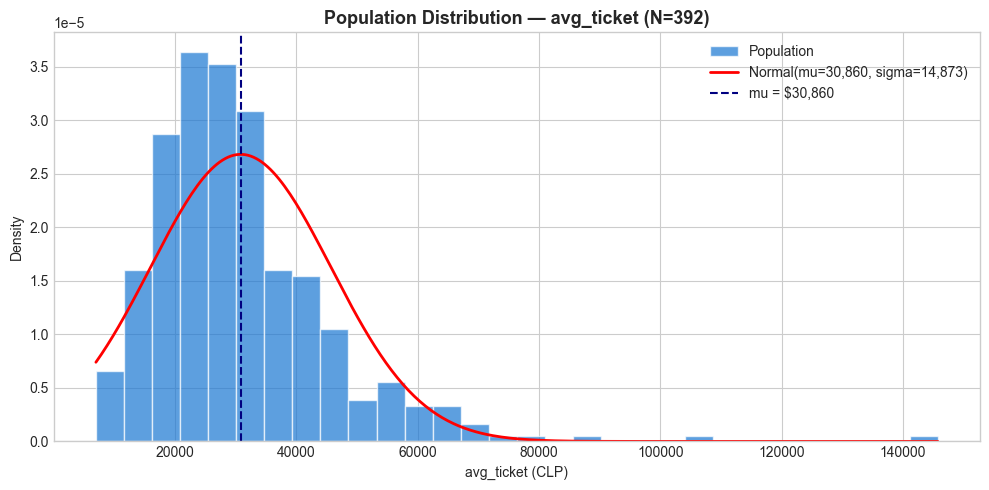

Figure saved: ..\reports\figures\04_population_distribution.png


In [3]:
# ===== Population Distribution =====
def plot_population_distribution(population: np.ndarray, mu: float, sigma: float) -> None:
    """Plots the population distribution of avg_ticket.

    Shows histogram with mean line and Normal curve overlay.

    Args:
        population: np.ndarray — full population values
        mu: float — population mean
        sigma: float — population standard deviation

    Returns:
        None
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(population, bins=30, density=True,
            color='#1976D2', alpha=0.7, edgecolor='white', label='Population')

    x = np.linspace(population.min(), population.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            'r-', lw=2, label=f'Normal(mu={mu:,.0f}, sigma={sigma:,.0f})')
    ax.axvline(mu, color='navy', linestyle='--', lw=1.5, label=f'mu = ${mu:,.0f}')

    ax.set_title('Population Distribution — avg_ticket (N=392)', fontsize=13, fontweight='bold')
    ax.set_xlabel('avg_ticket (CLP)')
    ax.set_ylabel('Density')
    ax.legend()

    plt.tight_layout()
    out = REPORTS_FIGURES / '04_population_distribution.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_population_distribution(population, mu, sigma)

---
## 4. Central Limit Theorem — Empirical Verification

We draw **1,000 repeated samples** of sizes n=10, 30, 50, 100, 200 from
the population and plot the distribution of sample means.

**Expected result:** As n increases, the sampling distribution of the mean
becomes more Normal and more concentrated around mu.


In [5]:
# ===== CLT Empirical Verification =====
N_SIMULATIONS = 1000
sample_sizes  = [10, 30, 50, 100, 200]

sampling_distributions = {}
for n in sample_sizes:
    means = [
        np.random.choice(population, size=n, replace=True).mean()
        for _ in range(N_SIMULATIONS)
    ]
    sampling_distributions[n] = np.array(means)

print(f'Simulations per sample size: {N_SIMULATIONS}')
print()
print(f'{"n":>6} | {"Mean of means":>15} | {"Std of means (SE)"}')
print('-' * 45)
for n, means in sampling_distributions.items():
    print(f'{n:>6} | ${means.mean():>12,.0f}  | ${means.std():>10,.0f}')
print()
print(f'Population mu    : ${mu:,.0f}')
print(f'Population sigma : ${sigma:,.0f}')

Simulations per sample size: 1000

     n |   Mean of means | Std of means (SE)
---------------------------------------------
    10 | $      30,725  | $     4,787
    30 | $      30,754  | $     2,779
    50 | $      30,869  | $     2,076
   100 | $      30,862  | $     1,466
   200 | $      30,857  | $     1,081

Population mu    : $30,860
Population sigma : $14,873


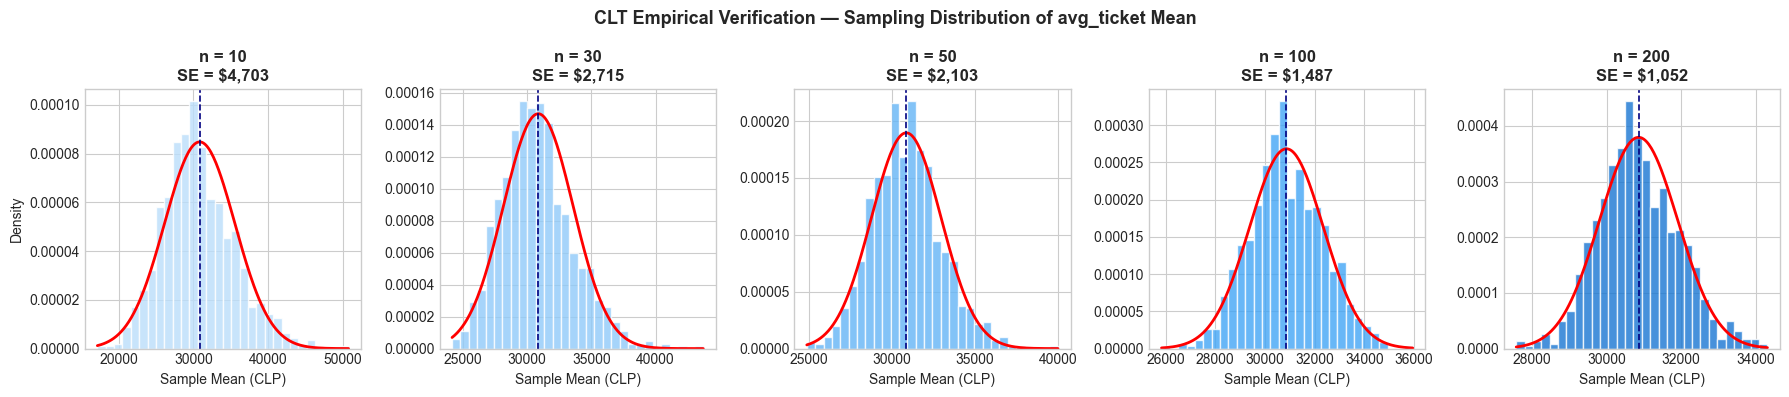

Figure saved: ..\reports\figures\04_clt_verification.png


In [6]:
# ===== CLT Visualization =====
def plot_clt_verification(
    sampling_distributions: dict,
    mu: float,
    sigma: float
) -> None:
    """Plots sampling distributions for each sample size to verify CLT.

    Shows histogram of sample means with theoretical Normal curve overlay
    for each sample size.

    Args:
        sampling_distributions: dict — {n: array of sample means}
        mu: float — population mean
        sigma: float — population standard deviation

    Returns:
        None
    """
    sample_sizes = list(sampling_distributions.keys())
    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(18, 4), sharey=False)
    fig.suptitle(
        'CLT Empirical Verification — Sampling Distribution of avg_ticket Mean',
        fontsize=13, fontweight='bold'
    )

    colors = ['#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#1976D2']

    for ax, n, color in zip(axes, sample_sizes, colors):
        means = sampling_distributions[n]
        se_theoretical = sigma / np.sqrt(n)

        ax.hist(means, bins=30, density=True,
                color=color, alpha=0.8, edgecolor='white')

        x = np.linspace(means.min(), means.max(), 200)
        ax.plot(x, stats.norm.pdf(x, mu, se_theoretical),
                'r-', lw=2, label='Theoretical Normal')
        ax.axvline(mu, color='navy', linestyle='--', lw=1.2)

        ax.set_title(f'n = {n}\nSE = ${se_theoretical:,.0f}', fontweight='bold')
        ax.set_xlabel('Sample Mean (CLP)')
        if ax == axes[0]:
            ax.set_ylabel('Density')

    plt.tight_layout()
    out = REPORTS_FIGURES / '04_clt_verification.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_clt_verification(sampling_distributions, mu, sigma)

---
## 5. Standard Error — SE = sigma / sqrt(n)

The Standard Error (SE) measures how much the sample mean is expected to
vary from the population mean. As n increases, SE decreases — the estimate
becomes more precise.

$$SE = \frac{\sigma}{\sqrt{n}}$$

This is the foundation of confidence intervals (notebook 05).


In [7]:
# ===== Standard Error Table & Plot =====
se_data = []
for n in [10, 30, 50, 100, 200, 392]:
    se_theoretical = sigma / np.sqrt(n)
    se_empirical   = sampling_distributions.get(n, np.array([np.nan])).std()
    se_data.append({
        'n': n,
        'SE theoretical (sigma/sqrt(n))': round(se_theoretical, 2),
        'SE empirical (from simulation)': round(se_empirical, 2) if not np.isnan(se_empirical) else 'N/A'
    })

df_se = pd.DataFrame(se_data)
print('STANDARD ERROR BY SAMPLE SIZE')
display(df_se)
print()
print(f'At n=392 (full census): SE = ${sigma / np.sqrt(n_pop):,.2f} CLP')

STANDARD ERROR BY SAMPLE SIZE


,n,SE theoretical (sigma/sqrt(n)),SE empirical (from simulation)
0,10,4703.36,4787.36
1,30,2715.48,2778.98
2,50,2103.40,2075.94
3,100,1487.33,1465.64
4,200,1051.70,1081.36
5,392,751.22,N/A



At n=392 (full census): SE = $751.22 CLP


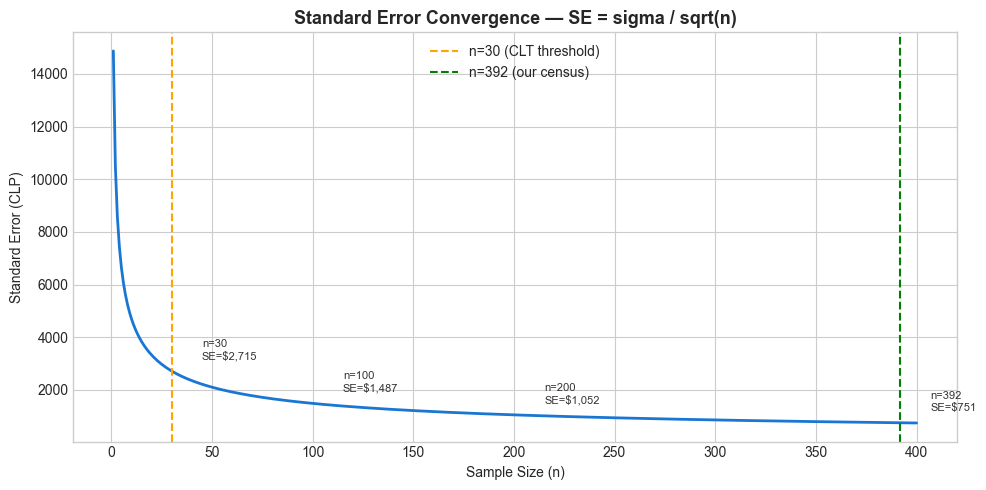

Figure saved: ..\reports\figures\04_se_convergence.png


In [8]:
# ===== SE Convergence Plot =====
def plot_se_convergence(sigma: float, n_max: int = 400) -> None:
    """Plots Standard Error as a function of sample size.

    Demonstrates how SE decreases as n increases (CLT consequence).

    Args:
        sigma: float — population standard deviation
        n_max: int — maximum sample size to plot

    Returns:
        None
    """
    n_values = np.arange(1, n_max + 1)
    se_values = sigma / np.sqrt(n_values)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(n_values, se_values, color='#1976D2', lw=2)
    ax.axvline(30,  color='orange', linestyle='--', lw=1.5, label='n=30 (CLT threshold)')
    ax.axvline(392, color='green',  linestyle='--', lw=1.5, label=f'n=392 (our census)')

    # Annotate key SE values
    for n_mark in [30, 100, 200, 392]:
        se_mark = sigma / np.sqrt(n_mark)
        ax.annotate(
            f'n={n_mark}\nSE=${se_mark:,.0f}',
            xy=(n_mark, se_mark),
            xytext=(n_mark + 15, se_mark + sigma * 0.03),
            fontsize=8, color='#333'
        )

    ax.set_title('Standard Error Convergence — SE = sigma / sqrt(n)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Standard Error (CLP)')
    ax.legend()

    plt.tight_layout()
    out = REPORTS_FIGURES / '04_se_convergence.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_se_convergence(sigma, n_max=400)

---
## 6. CLT Summary — Test Validity Confirmation

| Verification | Result | Implication |
|-------------|--------|-------------|
| Sampling distribution converges to Normal | ✅ Confirmed empirically (n>=30) | t-tests and ANOVA are valid |
| Mean of sampling distribution ≈ population mu | ✅ Confirmed | Unbiased estimator |
| SE = sigma/sqrt(n) — verified empirically | ✅ Theoretical ≈ Empirical | CI formula valid |
| n=392 >> 30 CLT threshold | ✅ Well above threshold | All parametric tests valid |

> **Conclusion:** The CLT holds for PequeShop's `avg_ticket`. All planned
> parametric tests (t-test H1, Welch H2, z-test H3, ANOVA H4) are statistically
> justified. Notebook 05 will use this foundation to build confidence intervals.


---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does CLT verification add value beyond notebook 03? | ✅ Yes — empirical proof, not just theory | Keep |
| Is n=1000 simulations justified? | ✅ Yes — standard for stable CLT demonstration | Keep |
| Do we need all 5 sample sizes? | ✅ Yes — shows progression from non-Normal to Normal | Keep all |
| Is the SE convergence plot necessary? | ✅ Yes — directly feeds notebook 05 CI calculations | Keep |
| Could we skip this notebook and just cite CLT? | ⚠️ Technically yes, but empirical verification is portfolio-grade evidence | Keep |


---
## 8. Decisions Log — Lesson 4

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use bootstrap resampling (with replacement) | Simulates repeated sampling from a fixed population; standard CLT demonstration method | Without replacement | ✅ Methodologically correct |
| 2 | N_SIMULATIONS = 1000 | Sufficient for stable distribution shape; standard in textbooks | 500 (less stable), 10000 (overkill) | ✅ MVA principle |
| 3 | Sample sizes: 10, 30, 50, 100, 200 | Shows transition below and above CLT threshold (n=30); 200 approaches census size | Only n=30 and n=100 | ✅ Tells a complete story |
| 4 | Include SE convergence plot separately | SE is the bridge between CLT (notebook 04) and CI (notebook 05) — deserves its own visualization | Embed in CLT plot | ✅ Cleaner narrative |


---
## 9. Next Steps — Lesson 5 Preview

In **Lesson 5 — Evaluation (notebook 05)**, the following tasks will be completed:

1. Calculate confidence intervals at 90%, 95%, and 99% for `avg_ticket`
2. Calculate confidence intervals for the churn rate (proportion)
3. Visualize how interval width changes with confidence level
4. Check whether the H1 benchmark ($25,000 CLP) falls inside/outside the CI
5. Check whether the H3 benchmark (30% churn) falls inside/outside the CI
6. Connect CI results to the expected outcomes of hypothesis tests in notebook 06

---

**Previous:** [03 - Data Preparation](./03_data_preparation.ipynb)  
**Next Phase -->** [05 - Evaluation](./05_evaluation.ipynb)
